In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('diabetic_data.csv')
print("Data loaded successfully!")
print(f"Shape: {df.shape}")

Data loaded successfully!
Shape: (101766, 50)


In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print(df.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [5]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [6]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
missing = df.isnull().sum()
print(missing[missing > 0])

max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [8]:
df.isnull().sum().sum()

np.int64(181168)

In [9]:
print(f"max_glu_serum missing: {96420/101766*100:.1f}%")
print(f"A1Cresult missing: {84748/101766*100:.1f}%")

max_glu_serum missing: 94.7%
A1Cresult missing: 83.3%


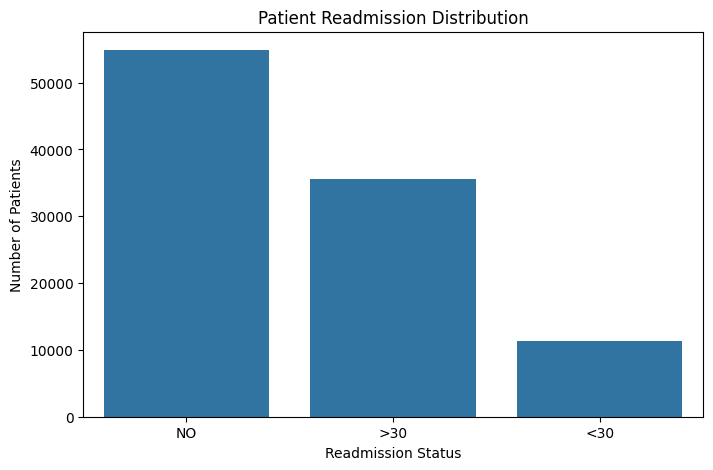

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='readmitted', order=['NO','>30','<30'])
plt.title('Patient Readmission Distribution')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.show()

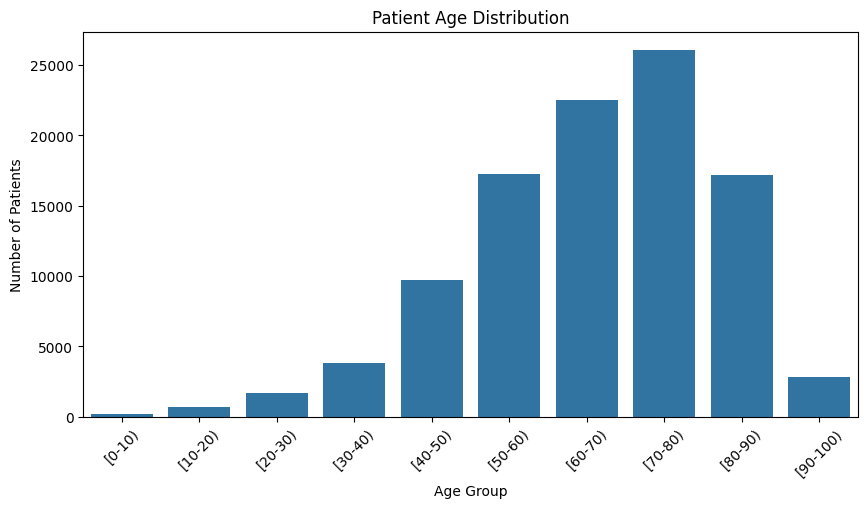

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='age')
plt.title('Patient Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

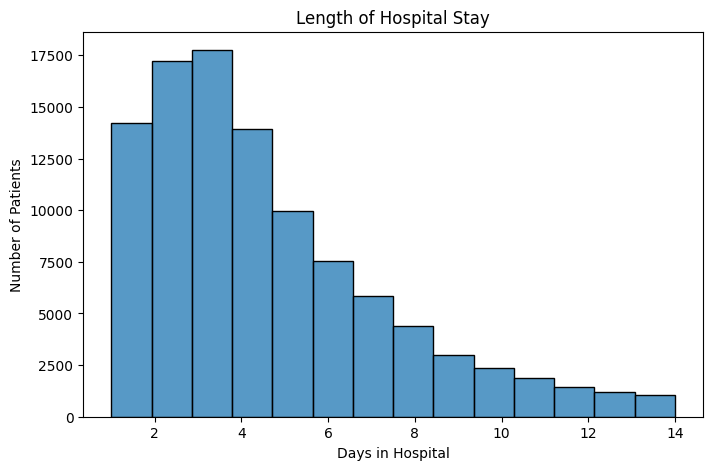

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='time_in_hospital', bins=14)
plt.title('Length of Hospital Stay')
plt.xlabel('Days in Hospital')
plt.ylabel('Number of Patients')
plt.show()

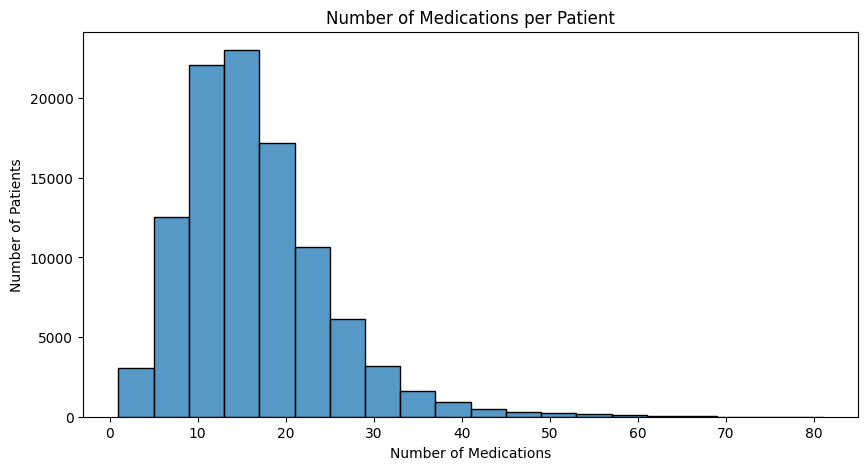

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='num_medications', bins=20)
plt.title('Number of Medications per Patient')
plt.xlabel('Number of Medications')
plt.ylabel('Number of Patients')
plt.show()

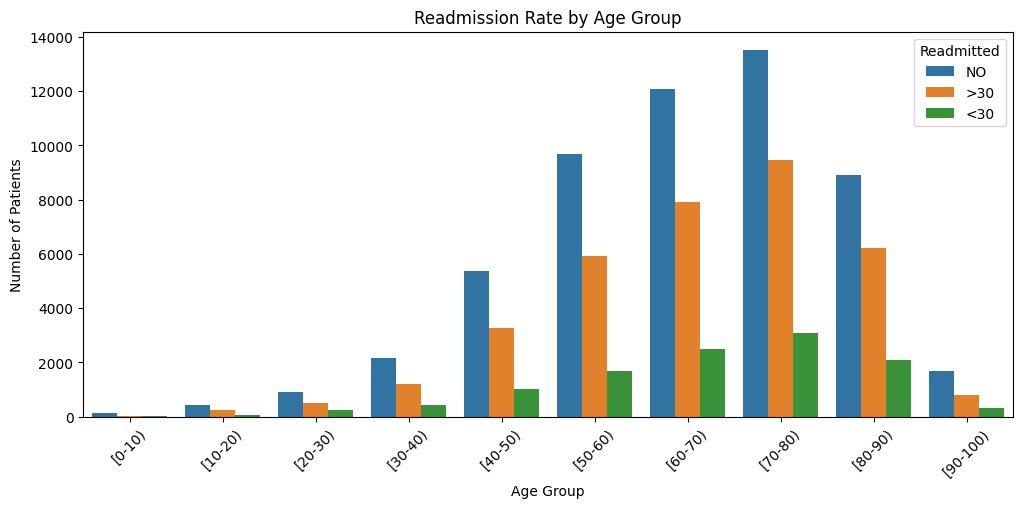

In [14]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='age', hue='readmitted')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.show()

In [15]:
print("=== DATASET SUMMARY ===")
print(f"Total patients: {len(df)}")
print(f"Total features: {len(df.columns)}")
print(f"\nReadmission breakdown:")
print(df['readmitted'].value_counts())
print(f"\nAverage hospital stay: {df['time_in_hospital'].mean():.1f} days")
print(f"Average medications: {df['num_medications'].mean():.1f}")
print(f"\nMissing value columns: max_glu_serum, A1Cresult")
print(f"Total missing values: {df.isnull().sum().sum()}")

=== DATASET SUMMARY ===
Total patients: 101766
Total features: 50

Readmission breakdown:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Average hospital stay: 4.4 days
Average medications: 16.0

Missing value columns: max_glu_serum, A1Cresult
Total missing values: 181168
